In [1]:
import torch
from torch import nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from mpl_toolkits.mplot3d import axes3d
import scipy.io
from torch.utils.data import DataLoader, random_split, TensorDataset
import pandas as pd
import time

from utils import GiveMeDataMuscleAbove, GiveMeDataMuscleBelow, CreateTensorLoader, plotplot, train_loop, test_loop, plotLossEpoch, plotSemilogyLossEpoch, train_loop_FA, test_loop_FA
%matplotlib inline
%matplotlib widget

In [2]:
file_path = r"C:\\Users\\gwang\\OneDrive - INSA Lyon\\code Python\\FastAdaptation\\code\\data_bm\\sinus_bigmuscle_0g.mat"
# Load the .mat file
mat = scipy.io.loadmat(file_path)
data_train = mat['data']

train_ratio = .8
batch_size = 128
seed = 666
gpu = 0
e_h, deh_dt, P_h, dPdt_h, q_h = GiveMeDataMuscleAbove(data_train)
train_loader, test_loader = CreateTensorLoader(e_h, deh_dt, P_h, dPdt_h, q_h, 1000, train_ratio, batch_size, seed, gpu)

Data in CPU currently.


In [3]:
class augmentedNet(nn.Module):
    def __init__(self):
        super(augmentedNet, self).__init__()
        self.net=nn.Sequential(
            nn.Linear(4,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,1,dtype=torch.float32),
            nn.Linear(1,1,dtype=torch.float32),
            )
    def forward(self, x):
        return self.net(x)

In [4]:
net_FA = augmentedNet()
pre_trained = torch.load('net_sm.pth', map_location=torch.device('cpu'))
net_FA_state = net_FA.state_dict()

for name, param in pre_trained.items():
    if name in net_FA_state and net_FA_state[name].size() == param.size():
        net_FA_state[name] = param
        print(f"Loaded {name}")
    else:
        print(f"Skipped {name}")

net_FA.load_state_dict(net_FA_state)

with torch.no_grad():
    net_FA.net[5].weight.fill_(4.0)
    net_FA.net[5].bias.fill_(0.0)
    
net_FA.train()
# net_FA.to('cuda') if gpu else net_FA.to('cpu')

loss_function = nn.MSELoss()
lr = 1e-4
optim = torch.optim.Adam([
    {'params': net_FA.net[0].parameters(), 'lr': lr},
    {'params': net_FA.net[2].parameters(), 'lr': lr},
    {'params': net_FA.net[4].parameters(), 'lr': lr},
    {'params': net_FA.net[5].weight, 'lr': lr * 0.2},  # weights
    {'params': net_FA.net[5].bias, 'lr': 0},         # biases frozen
], weight_decay=1e-5) 

Loaded net.0.weight
Loaded net.0.bias
Loaded net.2.weight
Loaded net.2.bias
Loaded net.4.weight
Loaded net.4.bias


In [ ]:
net_FA.state_dict()

In [5]:
Loss_train_FA = []
Loss_test_FA =[]

In [10]:
print("Model and data is currently on:", next(net_FA.parameters()).device)
print(f"Optimizer = {type(optim).__name__}\nLoss Function = {type(loss_function).__name__}")

target_loss=.001
start_time = time.time()
for t in range(1000):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_loader, net_FA, loss_function, optim, Loss_train_FA, batch_size)
    test_loss = test_loop(test_loader, net_FA, loss_function)
    Loss_test_FA.append(test_loss)
    if test_loss <= target_loss and train_loss <= target_loss:
        print(test_loss)
        break

end_time = time.time()
execution_time = end_time - start_time

Model and data is currently on: cpu
Optimizer = Adam
Loss Function = MSELoss
Epoch 1
-------------------------------
loss: 2.412826  [  128/  315]
Avg training loss: 1.296299
Avg Testing loss: 0.784267 

Epoch 2
-------------------------------
loss: 2.388709  [  128/  315]
Avg training loss: 1.296097
Avg Testing loss: 0.782889 

Epoch 3
-------------------------------
loss: 0.621860  [  128/  315]
Avg training loss: 1.295824
Avg Testing loss: 0.783151 

Epoch 4
-------------------------------
loss: 2.424071  [  128/  315]
Avg training loss: 1.295894
Avg Testing loss: 0.782620 

Epoch 5
-------------------------------
loss: 0.605571  [  128/  315]
Avg training loss: 1.295695
Avg Testing loss: 0.783274 

Epoch 6
-------------------------------
loss: 2.405535  [  128/  315]
Avg training loss: 1.295623
Avg Testing loss: 0.783621 

Epoch 7
-------------------------------
loss: 2.531744  [  128/  315]
Avg training loss: 1.295578
Avg Testing loss: 0.783604 

Epoch 8
--------------------------

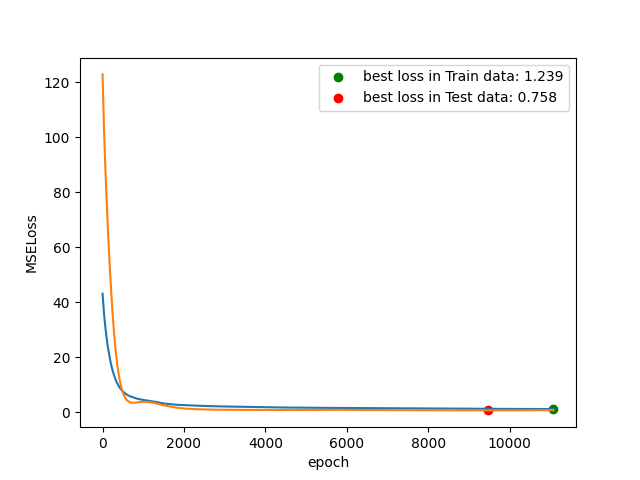

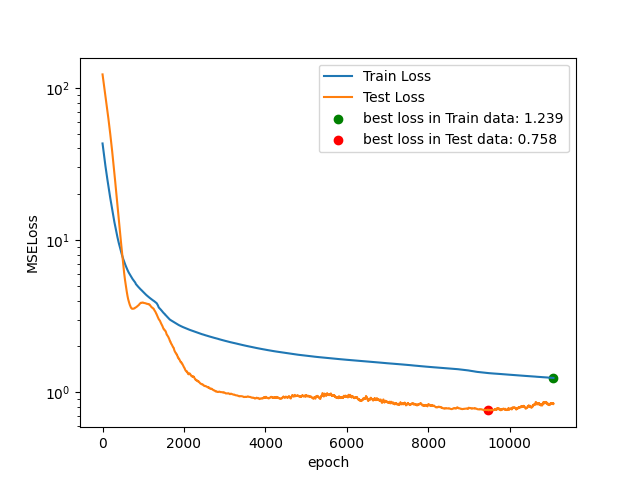

In [11]:
plotLossEpoch(Loss_train_FA, Loss_test_FA, 0, 'loss_FA.svg')
plotSemilogyLossEpoch(Loss_train_FA, Loss_test_FA, 0, 'semilogy_loss_FA.svg')

In [12]:
torch.save(net_FA.state_dict(), f"net_bm_FA.pth")
np.save(f"loss_bm_FA_train.npy", Loss_train_FA)
np.save(f"loss_bm_FA_test.npy", Loss_test_FA)